# Pre-Training Validation
## Wide & Deep Career Recommender — Environment & Data Checks

**Purpose:** Run every cell in this notebook before opening Notebook 11.
All checks must pass before training can begin.

**Checks performed:**
1. Environment — Python packages and device availability
2. File system — all required files present and non-empty
3. MindRecord schema — columns, shapes, and dtypes
4. Label encoders — vocab sizes for the Wide path
5. Data distribution — class balance, feature ranges, NaN/Inf scan
6. Go / No-Go summary

---

## Step 1: Environment Check

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ENVIRONMENT CHECK")
print("="*80)

print(f"\nPython version: {sys.version}")

ENVIRONMENT CHECK

Python version: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]


In [2]:
# Core scientific packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

print("✓ numpy  :", np.__version__)
print("✓ pandas :", pd.__version__)

✓ numpy  : 1.24.3
✓ pandas : 2.0.3


In [3]:
# MindSpore import
try:
    import mindspore as ms
    import mindspore.dataset as ds
    print("✓ MindSpore:", ms.__version__)
    MINDSPORE_OK = True
except ImportError as e:
    print("✗ MindSpore not found:", e)
    print("  Install: pip install mindspore==2.2.14")
    MINDSPORE_OK = False

✓ MindSpore: 2.8.0


In [4]:
# Device detection — safe for CPU-only environments (no nvidia-smi required)
import shutil
import subprocess

nvidia_smi = shutil.which("nvidia-smi")

if nvidia_smi is not None:
    result = subprocess.run(
        [nvidia_smi, "--query-gpu=name,memory.total,driver_version",
         "--format=csv,noheader"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print("GPU(s) detected:")
        for i, line in enumerate(result.stdout.strip().split("\n")):
            name, mem, driver = [x.strip() for x in line.split(",")]
            print(f"  GPU {i}: {name}  |  Memory: {mem}  |  Driver: {driver}")
        DEVICE_TARGET = "GPU"
    else:
        print("nvidia-smi found but returned an error — defaulting to CPU")
        DEVICE_TARGET = "CPU"
else:
    print("nvidia-smi not found on this system — using CPU")
    print("  This is expected on CPU-only machines.")
    DEVICE_TARGET = "CPU"

print(f"\n→ Device target set to: '{DEVICE_TARGET}'")

nvidia-smi not found on this system — using CPU
  This is expected on CPU-only machines.

→ Device target set to: 'CPU'


---
## Step 2: File System Check

In [5]:
print("="*80)
print("FILE SYSTEM CHECK")
print("="*80)

# Directories
data_dir    = Path('/workspace/data/processed')
mindrecord_dir = Path('/workspace/data/mindrecord')
viz_dir     = Path('/workspace/data/visualizations')

# Required files
REQUIRED = {
    "MindRecord data file"  : mindrecord_dir / 'widedeep_training.mindrecord',
    "MindRecord index file" : mindrecord_dir / 'widedeep_training.mindrecord.db',
    "Conversion metadata"   : mindrecord_dir / 'mindrecord_conversion_metadata.json',
    "Label encoders (pkl)"  : data_dir / 'label_encoders.pkl',
}

file_checks = {}
all_required_ok = True

print(f"\n{'File':<35} {'Status':<14} {'Size'}")
print("-"*65)

for label, path in REQUIRED.items():
    if path.exists():
        size_mb = path.stat().st_size / 1024 / 1024
        size_str = f"{size_mb:.1f} MB" if size_mb >= 0.1 else f"{path.stat().st_size} B"
        print(f"{label:<35} {'✓ found':<14} {size_str}")
        file_checks[label] = True
    else:
        print(f"{label:<35} {'✗ MISSING':<14} —")
        file_checks[label] = False
        all_required_ok = False

# Optional files
OPTIONAL = {
    "Training CSV"          : data_dir / 'unified_training_dataset_v3.csv',
    "User skill vectors"    : data_dir / 'user_skill_vectors.npy',
    "Simulation skill vecs" : data_dir / 'simulation_skill_vectors.npy',
}

print(f"\n{'Optional file':<35} {'Status'}")
print("-"*50)
for label, path in OPTIONAL.items():
    status = "✓ present" if path.exists() else "— not found"
    print(f"  {label:<33} {status}")

print()
if all_required_ok:
    print("✓ All required files present — ready to continue")
else:
    print("✗ STOP: Required files are missing.")
    print("  Run the MindRecord conversion notebook first.")

FILE_CHECK_OK = all_required_ok

FILE SYSTEM CHECK

File                                Status         Size
-----------------------------------------------------------------
MindRecord data file                ✓ found        55.3 MB
MindRecord index file               ✓ found        3.0 MB
Conversion metadata                 ✓ found        1240 B
Label encoders (pkl)                ✓ found        1348 B

Optional file                       Status
--------------------------------------------------
  Training CSV                      ✓ present
  User skill vectors                ✓ present
  Simulation skill vecs             ✓ present

✓ All required files present — ready to continue


---
## Step 3: MindRecord Schema Inspection

In [6]:
print("="*80)
print("MINDRECORD SCHEMA INSPECTION")
print("="*80)

import mindspore.dataset as ds

MINDRECORD_FILE = str(mindrecord_dir / 'widedeep_training.mindrecord')

# Load a small sample to inspect schema
try:
    sample_ds = ds.MindDataset(
        dataset_files=MINDRECORD_FILE,
        shuffle=False,
        num_parallel_workers=2
    ).batch(16)

    sample_iter = sample_ds.create_dict_iterator(output_numpy=True)
    sample_batch = next(sample_iter)
    del sample_iter

    print(f"\n{'Column':<40} {'Shape':<20} {'Dtype':<12} {'Min':>10} {'Max':>10}")
    print("-"*95)

    for col_name in sorted(sample_batch.keys()):
        arr = sample_batch[col_name]
        min_val = arr.min() if arr.dtype.kind in ('i','u','f') else '—'
        max_val = arr.max() if arr.dtype.kind in ('i','u','f') else '—'
        min_str = f"{float(min_val):.3f}" if isinstance(min_val, float) else str(min_val)
        max_str = f"{float(max_val):.3f}" if isinstance(max_val, float) else str(max_val)
        print(f"{col_name:<40} {str(arr.shape):<20} {str(arr.dtype):<12} {min_str:>10} {max_str:>10}")

    SCHEMA_OK = True
    print("\n✓ MindRecord schema loaded successfully")

except Exception as e:
    print(f"\n✗ Could not load MindRecord: {e}")
    sample_batch = {}
    SCHEMA_OK = False

MINDRECORD SCHEMA INSPECTION

Column                                   Shape                Dtype               Min        Max
-----------------------------------------------------------------------------------------------
analytical_score                         (16,)                int32                45         77
creative_score                           (16,)                int32                32         90
education_level_encoded                  (16,)                int32                 0          2
engagement_probability                   (16,)                float32       0.1102289  0.7935714
field_of_study_encoded                   (16,)                int32                 1          4
hands_on_score                           (16,)                int32                60         84
label                                    (16,)                int32                 0          1
linguistic_score                         (16,)                int32                51         75
s

In [7]:
# Verify the expected columns are all present
print("="*80)
print("COLUMN PRESENCE VERIFICATION")
print("="*80)

WIDE_COLS = [
    'education_level_encoded',
    'field_of_study_encoded',
    'simulation_categoria_encoded',
    'simulation_nivel_dificultad_encoded',
    'simulation_industria_encoded'
]

CONTINUOUS_COLS = [
    'analytical_score', 'creative_score', 'social_score',
    'linguistic_score', 'hands_on_score', 'simulation_duracion_horas'
]

SKILL_COLS   = ['user_skills', 'simulation_skills']
LABEL_COLS   = ['label', 'engagement_probability']

all_expected = WIDE_COLS + CONTINUOUS_COLS + SKILL_COLS + LABEL_COLS
found_cols   = list(sample_batch.keys())

print(f"\nWide (categorical) features:")
for col in WIDE_COLS:
    status = "✓" if col in found_cols else "✗"
    print(f"  {status} {col}")

print(f"\nDeep (continuous) features:")
for col in CONTINUOUS_COLS:
    status = "✓" if col in found_cols else "✗"
    print(f"  {status} {col}")

print(f"\nSkill vector features:")
for col in SKILL_COLS:
    arr = sample_batch.get(col)
    shape_str = str(arr.shape) if arr is not None else "MISSING"
    status = "✓" if col in found_cols else "✗"
    print(f"  {status} {col:<30} shape: {shape_str}")

print(f"\nLabel columns:")
for col in LABEL_COLS:
    status = "✓" if col in found_cols else "✗"
    print(f"  {status} {col}")

missing = [c for c in all_expected if c not in found_cols]
if missing:
    print(f"\n✗ Missing columns: {missing}")
    SCHEMA_OK = False
else:
    print("\n✓ All expected columns present")

COLUMN PRESENCE VERIFICATION

Wide (categorical) features:
  ✓ education_level_encoded
  ✓ field_of_study_encoded
  ✓ simulation_categoria_encoded
  ✓ simulation_nivel_dificultad_encoded
  ✓ simulation_industria_encoded

Deep (continuous) features:
  ✓ analytical_score
  ✓ creative_score
  ✓ social_score
  ✓ linguistic_score
  ✓ hands_on_score
  ✓ simulation_duracion_horas

Skill vector features:
  ✓ user_skills                    shape: (16, 52)
  ✓ simulation_skills              shape: (16, 52)

Label columns:
  ✓ label
  ✓ engagement_probability

✓ All expected columns present


In [8]:
# Compute expected model dimensions from the schema
if sample_batch:
    skill_dim  = sample_batch['user_skills'].shape[1]
    n_wide     = len(WIDE_COLS)
    n_cont     = len(CONTINUOUS_COLS)
    n_skills   = len(SKILL_COLS) * skill_dim
    deep_dim   = n_cont + n_skills

    print("="*80)
    print("MODEL DIMENSION SUMMARY")
    print("="*80)
    print(f"\nWide path:")
    print(f"  Categorical features : {n_wide}  (one embedding table each)")
    print(f"\nDeep path:")
    print(f"  Continuous scores    : {n_cont}")
    print(f"  Skill vector dim     : {skill_dim} x {len(SKILL_COLS)} vectors = {n_skills}")
    print(f"  Total deep_dim       : {deep_dim}")
    print(f"\nOutput:")
    print(f"  Single logit (binary classification — label 0/1)")
    print(f"  Loss: BCEWithLogitsLoss")

MODEL DIMENSION SUMMARY

Wide path:
  Categorical features : 5  (one embedding table each)

Deep path:
  Continuous scores    : 6
  Skill vector dim     : 52 x 2 vectors = 104
  Total deep_dim       : 110

Output:
  Single logit (binary classification — label 0/1)
  Loss: BCEWithLogitsLoss


---
## Step 4: Label Encoders Inspection

In [9]:
print("="*80)
print("LABEL ENCODERS INSPECTION")
print("="*80)

encoder_path = data_dir / 'label_encoders.pkl'

try:
    with open(encoder_path, 'rb') as f:
        encoders = pickle.load(f)

    print(f"\n✓ Loaded {len(encoders)} encoder(s) from label_encoders.pkl")
    print(f"\n{'Encoder name':<40} {'Type':<25} {'Vocab size':>12}")
    print("-"*80)

    WIDE_VOCAB_SIZES = []
    WIDE_ENCODER_NAMES = []

    for name, enc in encoders.items():
        if hasattr(enc, 'classes_'):
            vocab = len(enc.classes_)
            enc_type = 'LabelEncoder'
            sample_vals = list(enc.classes_[:3])
        elif isinstance(enc, dict):
            vocab = len(enc)
            enc_type = 'dict'
            sample_vals = list(enc.keys())[:3]
        else:
            vocab = '?'
            enc_type = type(enc).__name__
            sample_vals = []

        print(f"  {name:<38} {enc_type:<25} {str(vocab):>12}")
        if sample_vals:
            print(f"  {'':38} sample values: {sample_vals}")

        # Collect wide feature encoders in the expected order
        WIDE_VOCAB_SIZES.append(vocab if isinstance(vocab, int) else 0)
        WIDE_ENCODER_NAMES.append(name)

    print(f"\nWide vocab sizes (in encoder order):")
    for name, vocab in zip(WIDE_ENCODER_NAMES, WIDE_VOCAB_SIZES):
        print(f"  {name:<40}: {vocab}")

    ENCODER_OK = True

except FileNotFoundError:
    print(f"\n✗ label_encoders.pkl not found at {encoder_path}")
    WIDE_VOCAB_SIZES = []
    WIDE_ENCODER_NAMES = []
    ENCODER_OK = False

LABEL ENCODERS INSPECTION

✓ Loaded 5 encoder(s) from label_encoders.pkl

Encoder name                             Type                        Vocab size
--------------------------------------------------------------------------------
  education_level                        LabelEncoder                         4
                                         sample values: ["Bachelor's", 'High School', "Master's"]
  field_of_study                         LabelEncoder                        13
                                         sample values: ['Arts', 'Business', 'Commerce']
  simulation_categoria                   LabelEncoder                         8
                                         sample values: ['Business', 'Design', 'Education']
  simulation_nivel_dificultad            LabelEncoder                         5
                                         sample values: ['Advanced', 'Beginner', 'Expert']
  simulation_industria                   LabelEncoder                      

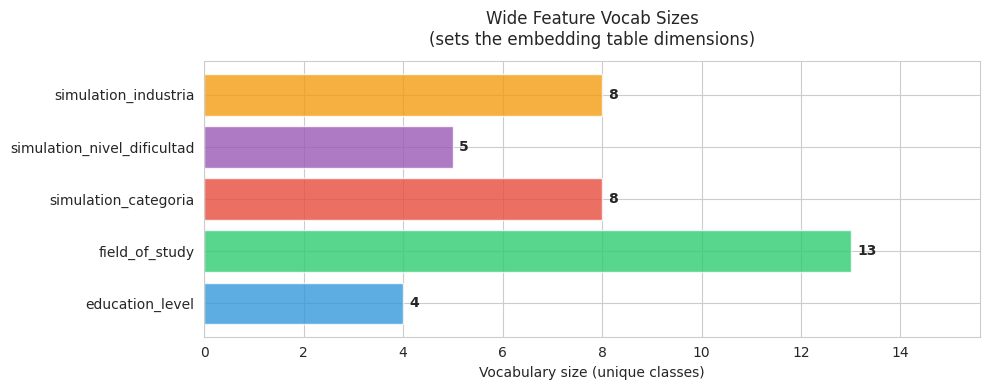


✓ Vocab size chart saved


In [10]:
# Visualize vocab sizes
if WIDE_VOCAB_SIZES:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
    bars = ax.barh(WIDE_ENCODER_NAMES, WIDE_VOCAB_SIZES, color=colors[:len(WIDE_VOCAB_SIZES)], alpha=0.8)
    for bar, val in zip(bars, WIDE_VOCAB_SIZES):
        ax.text(bar.get_width() + max(WIDE_VOCAB_SIZES)*0.01, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontweight='bold')
    ax.set_xlabel('Vocabulary size (unique classes)')
    ax.set_title('Wide Feature Vocab Sizes\n(sets the embedding table dimensions)', pad=12)
    ax.set_xlim(0, max(WIDE_VOCAB_SIZES) * 1.2)
    plt.tight_layout()
    plt.savefig(viz_dir / 'nb10_vocab_sizes.png' if viz_dir.exists() else '/tmp/vocab_sizes.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Vocab size chart saved")

---
## Step 5: Data Distribution Analysis

In [11]:
print("="*80)
print("LOADING FULL DATASET FOR DISTRIBUTION ANALYSIS")
print("="*80)

import mindspore.dataset as ds

# Load ALL labels and a sample of features for analysis
# We read label + continuous columns only to keep memory usage low

COLS_TO_LOAD = ['label', 'engagement_probability',
                'analytical_score', 'creative_score', 'social_score',
                'linguistic_score', 'hands_on_score', 'simulation_duracion_horas',
                'user_skills']

print("\nReading all samples from MindRecord (this may take a few minutes) ...")

data_store = {col: [] for col in COLS_TO_LOAD}
data_store['user_skill_count'] = []

count = 0
full_ds = ds.MindDataset(
    dataset_files=MINDRECORD_FILE,
    columns_list=COLS_TO_LOAD,
    shuffle=False,
    num_parallel_workers=4
)

for sample in full_ds.create_dict_iterator(num_epochs=1, output_numpy=True):
    for col in COLS_TO_LOAD:
        if col == 'user_skills':
            data_store['user_skill_count'].append(int(sample[col].sum()))
        else:
            data_store[col].append(float(sample[col]))
    count += 1
    if count % 10000 == 0:
        print(f"  Read {count:,} samples ...")

print(f"\n✓ Loaded {count:,} total samples")

# Convert to arrays
for col in COLS_TO_LOAD:
    if col != 'user_skills':
        data_store[col] = np.array(data_store[col])
data_store['user_skill_count'] = np.array(data_store['user_skill_count'])

LOADING FULL DATASET FOR DISTRIBUTION ANALYSIS

Reading all samples from MindRecord (this may take a few minutes) ...
  Read 10,000 samples ...

✓ Loaded 18,501 total samples


In [12]:
print("="*80)
print("LABEL DISTRIBUTION")
print("="*80)

labels      = data_store['label'].astype(int)
n_total     = len(labels)
n_positive  = (labels == 1).sum()
n_negative  = (labels == 0).sum()
pos_rate    = n_positive / n_total * 100

print(f"\nTotal samples   : {n_total:,}")
print(f"Positive (label=1): {n_positive:,}  ({pos_rate:.2f}%)")
print(f"Negative (label=0): {n_negative:,}  ({100-pos_rate:.2f}%)")

imbalance_ratio = n_negative / n_positive if n_positive > 0 else float('inf')
print(f"Imbalance ratio : {imbalance_ratio:.1f}:1 (negative:positive)")

if imbalance_ratio > 10:
    print("\n⚠  High class imbalance detected.")
    print("   Consider: weighted loss, oversampling positives, or threshold tuning.")
elif imbalance_ratio > 3:
    print("\n⚠  Moderate class imbalance.")
    print("   Monitor precision/recall alongside accuracy during training.")
else:
    print("\n✓ Class balance is acceptable")

LABEL DISTRIBUTION

Total samples   : 18,501
Positive (label=1): 4,871  (26.33%)
Negative (label=0): 13,630  (73.67%)
Imbalance ratio : 2.8:1 (negative:positive)

✓ Class balance is acceptable


In [13]:
print("="*80)
print("CONTINUOUS FEATURE STATISTICS")
print("="*80)

cont_cols = ['analytical_score', 'creative_score', 'social_score',
             'linguistic_score', 'hands_on_score', 'simulation_duracion_horas']

print(f"\n{'Feature':<30} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'NaN':>6}")
print("-"*72)

nan_found = False
for col in cont_cols:
    arr = data_store[col]
    n_nan = int(np.isnan(arr).sum())
    if n_nan > 0:
        nan_found = True
    print(f"{col:<30} {arr.min():>8.2f} {arr.max():>8.2f} {arr.mean():>8.2f} {arr.std():>8.2f} {n_nan:>6}")

print()
if nan_found:
    print("✗ NaN values detected! Fix preprocessing before training.")
else:
    print("✓ No NaN values in continuous features")

CONTINUOUS FEATURE STATISTICS

Feature                             Min      Max     Mean      Std    NaN
------------------------------------------------------------------------
analytical_score                  35.00    95.00    70.44    15.51      0
creative_score                    25.00    98.00    51.69    14.90      0
social_score                      30.00    95.00    63.99    17.99      0
linguistic_score                  40.00    95.00    67.81    15.85      0
hands_on_score                    40.00    90.00    62.46    11.79      0
simulation_duracion_horas          3.00    20.00     9.87     5.08      0

✓ No NaN values in continuous features


FEATURE DISTRIBUTION VISUALIZATIONS


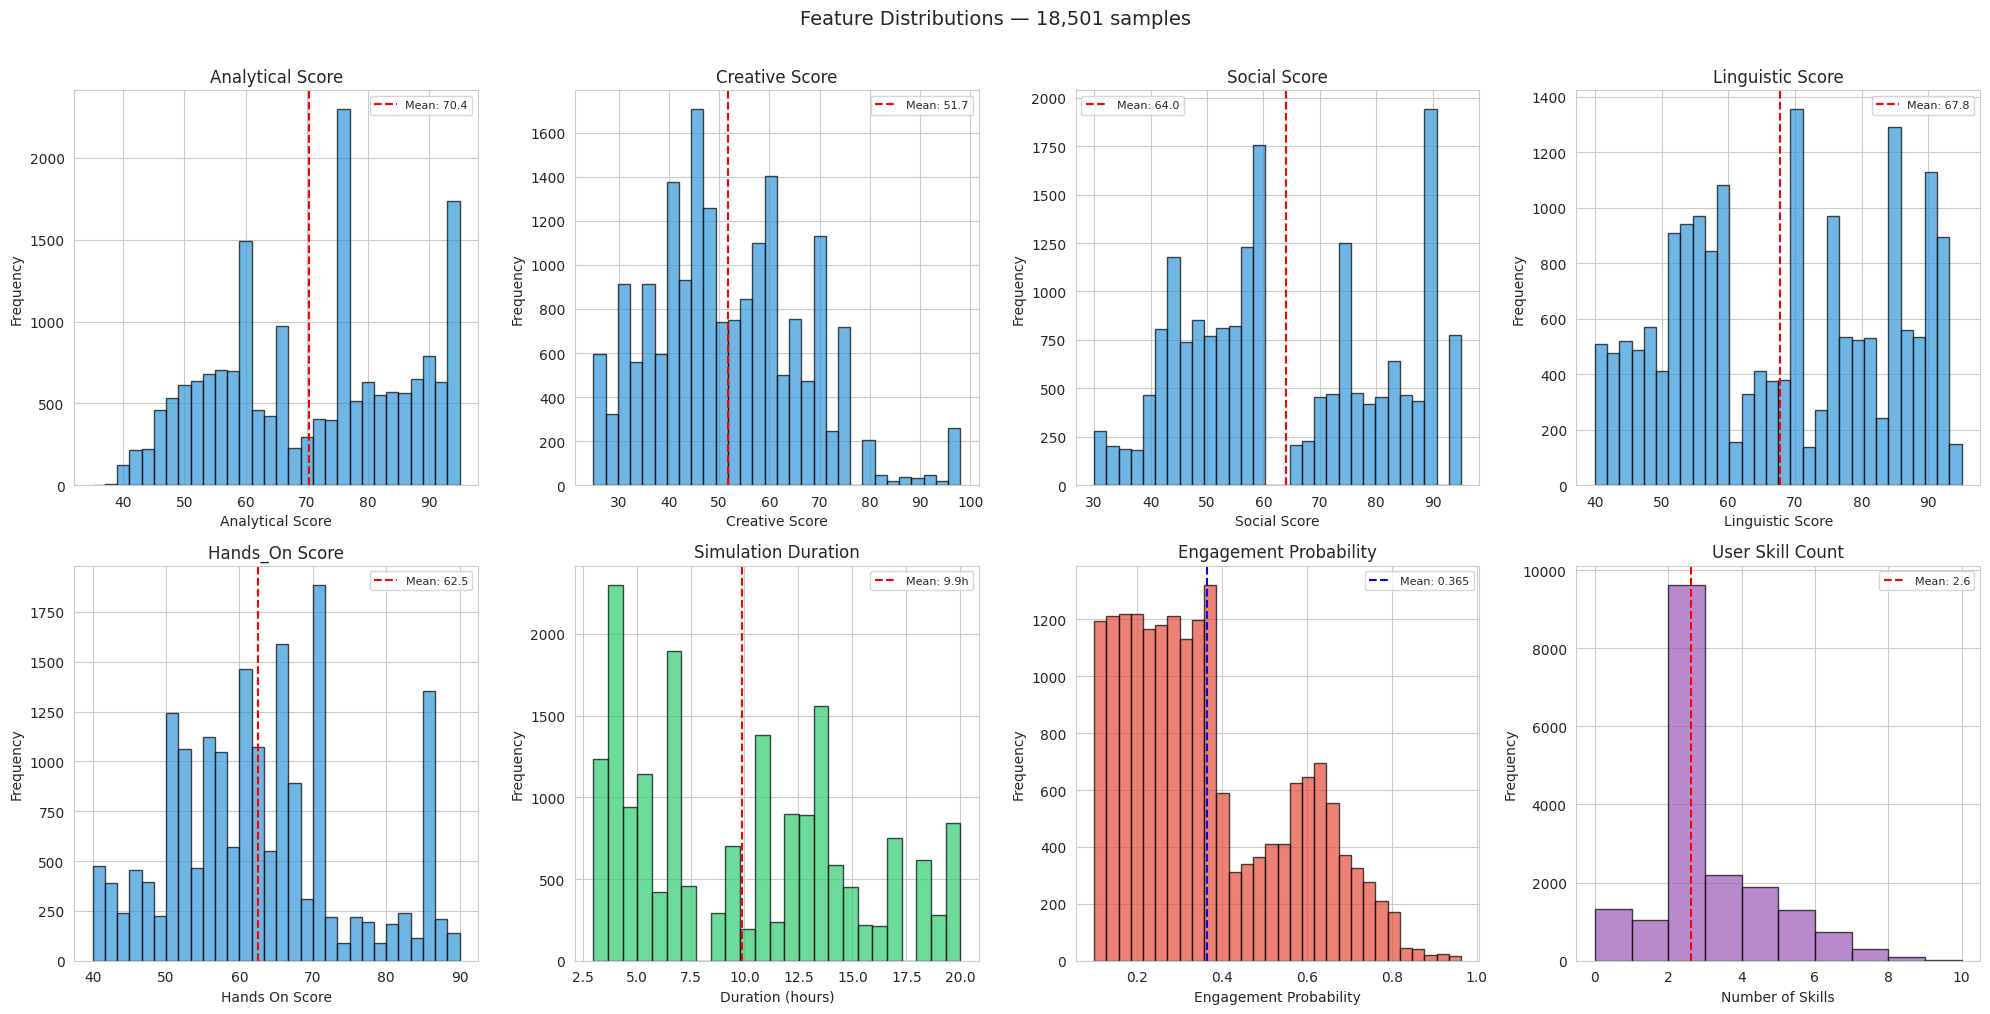


✓ Distribution charts saved to /workspace/data/visualizations/nb10_distributions.png


In [14]:
# Distribution plots
print("="*80)
print("FEATURE DISTRIBUTION VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

score_features = ['analytical_score', 'creative_score', 'social_score',
                  'linguistic_score', 'hands_on_score']

for idx, feature in enumerate(score_features):
    ax = axes[idx // 4, idx % 4]
    ax.hist(data_store[feature], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature.replace("_score","").title()} Score')
    ax.axvline(np.mean(data_store[feature]), color='red', linestyle='--',
               label=f'Mean: {np.mean(data_store[feature]):.1f}')
    ax.legend(fontsize=8)

# Duration
ax = axes[1, 1]
ax.hist(data_store['simulation_duracion_horas'], bins=25, color='#2ecc71', edgecolor='black', alpha=0.7)
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Frequency')
ax.set_title('Simulation Duration')
ax.axvline(np.mean(data_store['simulation_duracion_horas']), color='red', linestyle='--',
           label=f'Mean: {np.mean(data_store["simulation_duracion_horas"]):.1f}h')
ax.legend(fontsize=8)

# Engagement probability
ax = axes[1, 2]
ax.hist(data_store['engagement_probability'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax.set_xlabel('Engagement Probability')
ax.set_ylabel('Frequency')
ax.set_title('Engagement Probability')
ax.axvline(np.mean(data_store['engagement_probability']), color='blue', linestyle='--',
           label=f'Mean: {np.mean(data_store["engagement_probability"]):.3f}')
ax.legend(fontsize=8)

# User skill count
ax = axes[1, 3]
ax.hist(data_store['user_skill_count'], bins=range(int(data_store['user_skill_count'].min()),
                                                    int(data_store['user_skill_count'].max())+2),
        color='#9b59b6', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Skills')
ax.set_ylabel('Frequency')
ax.set_title('User Skill Count')
ax.axvline(data_store['user_skill_count'].mean(), color='red', linestyle='--',
           label=f'Mean: {data_store["user_skill_count"].mean():.1f}')
ax.legend(fontsize=8)

plt.suptitle(f'Feature Distributions — {n_total:,} samples', fontsize=14, y=1.01)
plt.tight_layout()
save_path = viz_dir / 'nb10_distributions.png' if viz_dir.exists() else Path('/tmp/nb10_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Distribution charts saved to {save_path}")

---
## Step 6: Go / No-Go Summary

In [15]:
print("="*80)
print("PRE-TRAINING VALIDATION — FINAL REPORT")
print("="*80)

checks = {
    "MindSpore importable"         : MINDSPORE_OK,
    "All required files present"   : FILE_CHECK_OK,
    "MindRecord schema valid"      : SCHEMA_OK,
    "Label encoders loaded"        : ENCODER_OK,
    "No NaN in continuous features": not nan_found,
    "Device target identified"     : True,
}

BLOCKING = {
    "MindSpore importable",
    "All required files present",
    "MindRecord schema valid",
    "Label encoders loaded",
}

print()
all_pass = True
blocker_fail = False

for check_name, passed in checks.items():
    is_blocking = check_name in BLOCKING
    symbol = "✓" if passed else ("✗" if is_blocking else "⚠")
    tag    = "  [BLOCKING]" if not passed and is_blocking else ""
    print(f"  {symbol}  {check_name}{tag}")
    if not passed:
        all_pass = False
        if is_blocking:
            blocker_fail = True

print()
print("="*80)
if all_pass:
    print("  ALL CHECKS PASSED")
    print("  → Proceed to Notebook 11: Model Build & Train")
elif blocker_fail:
    print("  BLOCKING ISSUES DETECTED")
    print("  → Fix the ✗ items above before running Notebook 11")
else:
    print("  NON-BLOCKING WARNINGS")
    print("  → Review the ⚠ items, then proceed with caution")
print("="*80)

print(f"\nConfiguration captured for Notebook 11:")
print(f"  DEVICE_TARGET     = '{DEVICE_TARGET}'")
print(f"  WIDE_VOCAB_SIZES  = {WIDE_VOCAB_SIZES}")
if sample_batch:
    skill_dim = sample_batch['user_skills'].shape[1]
    deep_dim  = len(CONTINUOUS_COLS) + 2 * skill_dim
    print(f"  deep_dim          = {deep_dim}  ({len(CONTINUOUS_COLS)} continuous + 2×{skill_dim} skill)")
print(f"  n_total_samples   = {n_total:,}")
print(f"  positive_rate     = {pos_rate:.2f}%")

PRE-TRAINING VALIDATION — FINAL REPORT

  ✓  MindSpore importable
  ✓  All required files present
  ✓  MindRecord schema valid
  ✓  Label encoders loaded
  ✓  No NaN in continuous features
  ✓  Device target identified

  ALL CHECKS PASSED
  → Proceed to Notebook 11: Model Build & Train

Configuration captured for Notebook 11:
  DEVICE_TARGET     = 'CPU'
  WIDE_VOCAB_SIZES  = [4, 13, 8, 5, 8]
  deep_dim          = 110  (6 continuous + 2×52 skill)
  n_total_samples   = 18,501
  positive_rate     = 26.33%
